In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
import pylab as pl
import numpy.linalg as linalg
import sys
import seaborn as sns
import numpy as np

def preprocess_data():

    data = pd.read_csv("../../Utils/Climate_Deniers_15K.csv")
    target = "climatedeniers_2"

    if target == "climatedeniers_2":
        data.drop(["climate_eb_problem", "climate_state_convinced", "climatedeniers_1", "climate_risk", "d_q1_own_opinion"], axis=1, inplace=True)
    elif target == "climatedeniers_1":
        data.drop(["climate_eb_problem", "climate_state_convinced", "climatedeniers_2", "climate_risk", "d_q1_own_opinion"], axis=1, inplace=True)
    
    data.dropna(inplace=True)
    
    data = pd.get_dummies(
            data,
            columns=["gender", "eastger", "academic", "migration_b_germany"], drop_first=True, dtype=float
        )
    
    oe_income = OrdinalEncoder(
        categories=[
            ['<= 200 EUR', '200 - 300 EUR', '300 - 400 EUR', '400 - 500 EUR', '500 - 625 EUR', '625 - 750 EUR',
             '750 - 875 EUR', '875 - 1000 EUR', '1000 - 1125 EUR', '1125 - 1250 EUR', '1250 - 1375 EUR',
             '1375 - 1500 EUR', '1500 - 1750 EUR', '1750 - 2000 EUR', '2000 - 2250 EUR', '2250 - 2500 EUR',
             '2500 - 2750 EUR', '2750 - 3000 EUR', '3000 - 4000 EUR', '4000 - 5000 EUR', '5000 - 7500 EUR',
             '>=7500 EUR']])
    data["income_section"] = oe_income.fit_transform(data[["income_section"]])
    oe_education = OrdinalEncoder(categories=[['No degree', 'Hauptschule', 'Realschule', 'Abitur', 'Lehre', 'Hochschule',
                                      'Doktor, Habilitation']])
    data["education"] = oe_education.fit_transform(data[["education"]])
    oe_children = OrdinalEncoder(categories=[['None', '1', '2', '3', '4', '5 or more']])
    data["children"] = oe_children.fit_transform(data[["children"]])
    oe_innovation = OrdinalEncoder(categories=[['Completely disagree', 'Rather disagree', 'Neither agree nor disagree',
                                      'Rather agree', 'Completely agree']])
    data["innovation"] = oe_innovation.fit_transform(data[["innovation"]])
    oe_moral = OrdinalEncoder(categories=[['Not at all relevant', 'Not very relevant', 'Somewhat relevant',
                                      'Slightly relevant', 'Very relevant', 'Extremely relevant']])
    data["moral_rel_love_country"] = oe_moral.fit_transform(data[["moral_rel_love_country"]])

    data["subject_well_being"].replace("Completely satisfied", 10, inplace=True)
    data["subject_well_being"].replace("Not satisfied at all", 10, inplace=True)
    
    y = data[target]
    X = data.drop([target], axis=1)
    
    print("No Samples:\t%d" % X.shape[0])
    print("No Features:\t%d" % X.shape[1])
    print("Feature Names:\t" + str(data.columns.tolist()))
    print("No of classes:\t%d" % np.unique(y).shape[0])

    return data, X, y

In [27]:
def pca(X, n_components=2):

    pca = PCA()
    pca.fit(X)
    
    pl.figure(figsize=(14,6))
    n=18
    
    ax = pl.subplot(111)
    ax.bar(np.arange(1,1+len(pca.explained_variance_[0:n])),pca.explained_variance_ratio_[0:n]*100)
    ax.plot(np.arange(1,1+len(pca.explained_variance_[0:n])), np.cumsum(pca.explained_variance_ratio_[0:n])*100,color="tab:green", label="Cumulative Variance Explained")
    ax.set_xticks(np.arange(1,1+len(pca.explained_variance_[0:n])))
    ax.set_yticks([10,20,30,40,50,60,70,80,90,100])
    pl.axhline(90,color="tab:orange",linestyle="dashed",label="90% Threshold")
    
    ax.grid(color="#CCCCCC")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel("Principal Components")
    ax.set_ylabel("Variance Explained in %")
    pl.legend()
    pl.tight_layout()

    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot()
    
    colors = ["red", "yellow"]
    
    ax.scatter(X_pca[y==0,0],X_pca[y==0,1],alpha=0.5,label="Class 0",zorder=30,c=colors[0])
    ax.scatter(X_pca[y==1,0],X_pca[y==1,1],alpha=0.75,label="Class 1",zorder=30,c=colors[1])
    
    ax.grid(color="#CCCCCC")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    pl.legend()
    pl.tight_layout()

In [28]:
def tsne(n_components=2):

    tsne = TSNE(n_components=n_components)
    X_tsne = tsne.fit_transform(X)
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot()
    
    ax.scatter(X_tsne[y==0,0],X_tsne[y==0,1],alpha=0.25,label="Class 0",zorder=30,c=colors[0])
    ax.scatter(X_tsne[y==1,0],X_tsne[y==1,1],label="Class 1",zorder=30,c=colors[1])
    
    ax.grid(color="#CCCCCC")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    pl.legend()
    pl.tight_layout()

In [29]:
def spectralclustering():

    np.set_printoptions(threshold=sys.maxsize)
    
    sc = SpectralClustering(n_clusters=4, eigen_solver="arpack", affinity="nearest_neighbors", n_components=2)
    X_sc = sc.fit(X_pca).labels_.astype(int)
    print(X_sc)
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot()
    
    ax.scatter(X_pca[X_sc==0,0],X_pca[X_sc==0,1],label="Class 0",zorder=30,c=colors[0])
    ax.scatter(X_pca[X_sc==1,0],X_pca[X_sc==1,1],label="Class 1",zorder=30,c=colors[1])
    
    ax.grid(color="#CCCCCC")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    pl.legend()
    pl.tight_layout()

In [30]:
def shift_dataset(data):
    # print(data["climate_state_convinced"].value_counts())
    # data["climatedeniers_2"][data["climate_state_convinced"] == "Completely agree"] = 0
    # data["climatedeniers_2"][data["climate_state_convinced"] == "Rather agree"] = 0
    # data["climatedeniers_2"][data["climate_state_convinced"] == "Rather disagree"] = 1
    # data["climatedeniers_2"][data["climate_state_convinced"] == "Completely disagree"] = 1
    # data["climatedeniers_2"].value_counts()

    data.replace("A very serious problem", int(10), inplace=True) 
    data.replace("No serious problem at all", int(1), inplace=True) 
    data["climate_eb_problem_1"] = data["climate_eb_problem_1"].astype("float")

    data["climatedeniers_1"] = 2
    
    data["climatedeniers_1"][data["climate_eb_problem_1"] <= 4.99] = 1
    data["climatedeniers_1"][data["climate_eb_problem_1"] > 4.99] = 0
    print(data["climatedeniers_1"].value_counts())

    return data

In [31]:
def boxplots():

    climatedeniers_target_0 = data[data[target] == 0]
    climatedeniers_target_1 = data[data[target] == 1]
    
    climatedeniers_target_0.drop([target], axis=1)
    climatedeniers_target_1.drop([target], axis=1)
    
    sns.set_theme(rc={'figure.figsize':(20,15)})
    # pd.melt converts the dataframe to long form, pd.concat combines them
    df = pd.concat({'climatedeniers_target_0': climatedeniers_target_0.melt(), 'climatedeniers_target_1': climatedeniers_target_1.melt()}, names=['source', 'old_index'])
    # convert the source index to a column, and reset the old index
    df = df.reset_index(level=0).reset_index(drop=True)
    df["value"] = df["value"].astype("float")

    ax = sns.boxplot(data=df, x='variable', y='value', hue='source', palette='turbo')
    ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
    
    plt.savefig("boxplots_" + target + ".svg")

In [32]:
data, X, y = preprocess_data()

No Samples:	8089
No Features:	18
Feature Names:	['age', 'income_section', 'education', 'children', 'subject_well_being', 'innovation', 'moral_rel_love_country', 'politics_orientation', 'patience', 'risk', 'posrecip', 'negrecip', 'altruism', 'trust', 'climatedeniers_2', 'gender_Male', 'eastger_west', 'academic_non-academic', 'migration_b_germany_Yes']
No of classes:	2


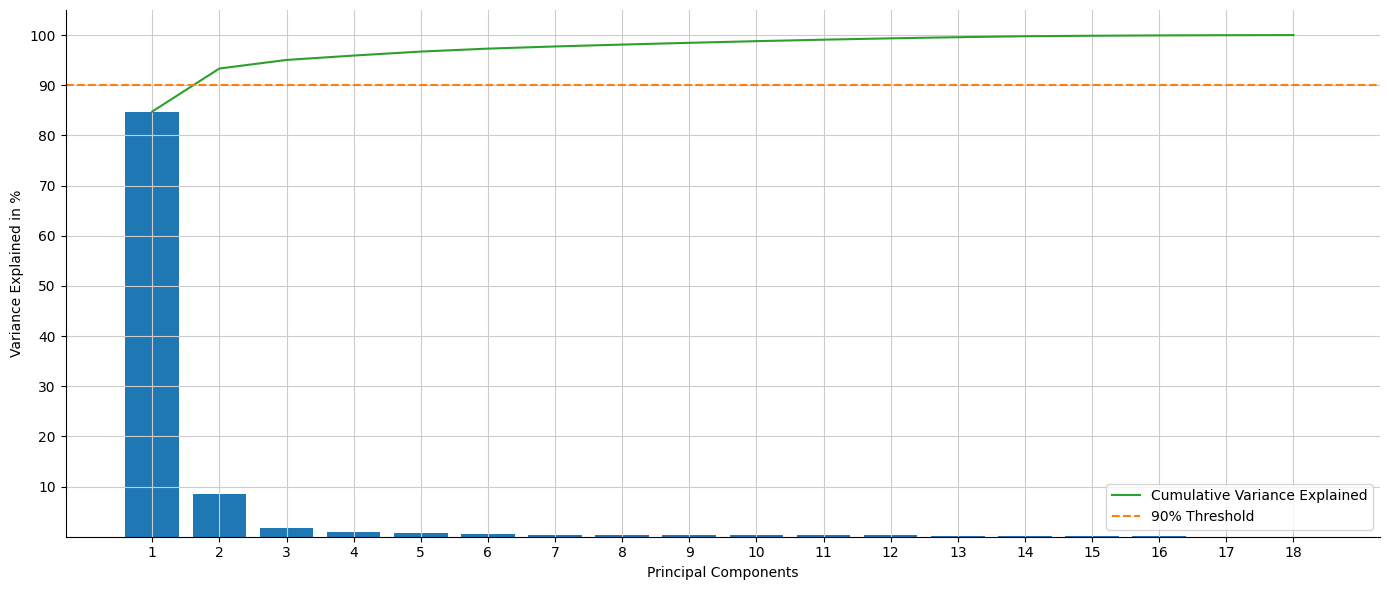

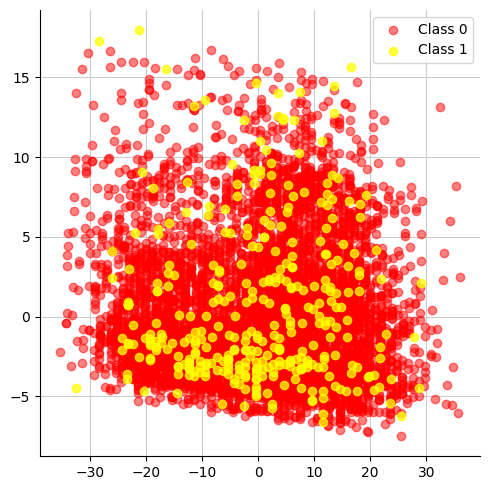

In [33]:
pca(X)

In [34]:
boxplots()

NameError: name 'target' is not defined

In [37]:
data = pd.read_excel("../../Utils/Bioeconomy Germany_labeled.xlsx", skiprows=lambda x: x in [1])

/usr/local/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [38]:
data.drop(
    ["StartDate", "EndDate", "RecordedDate", "Duration (in seconds)", "tic", "IPAddress", "ResponseId", "treatment", "control", 
     "econ_indicators", "ei_randomization", "mixed", "Status", "Progress", "Finished", "DistributionChannel", "UserLanguage", 
     "attention_check_1", "attention_check_2"], 
    inplace=True, axis=1)

In [39]:
percent_missing = data.isnull().sum() * 100 / len(data)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  
    print(percent_missing.sort_values())
percent_missing = data.isnull().sum(axis=1) * 100 / len(data)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(percent_missing.sort_values())

goal                           0.000000
religion_practice              0.000000
unemployment_count             0.000000
migration_b_germany            0.000000
unemployment_rate              0.000000
migration_s_germany            0.000000
adequacy                       0.000000
region_prefix                  0.000000
migration_region               0.000000
innovation                     0.000000
b_q1_distribution_1            0.000000
b_q1_distribution_2            0.000000
b_q1_distribution_3            0.000000
b_q1_distribution_4            0.000000
b_q1_distribution_5            0.000000
income.1                       0.000000
religion                       0.000000
job_field_2                    0.000000
b_q1_own_opinion               0.000000
job                            0.000000
gender                         0.000000
patent                         0.000000
treat_info                     0.000000
age                            0.000000
income                         0.000000


In [40]:
data_dropna = data.dropna(thresh=12750, axis=1)

In [41]:
data_dropna_targets = shift_dataset(data_dropna)

climatedeniers_1
0    13174
1     1832
2        1
Name: count, dtype: int64


/var/folders/vp/f7spj9ps2wgdx_m8415lqh9r03s583/T/ipykernel_33040/3961457415.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.replace("A very serious problem", int(10), inplace=True)
/var/folders/vp/f7spj9ps2wgdx_m8415lqh9r03s583/T/ipykernel_33040/3961457415.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.replace("No serious problem at all", int(1), inplace=True)
/var/folders/vp/f7spj9ps2wgdx_m8415lqh9r03s583/T/ipykernel_33040/3961457415.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

In [42]:
data_dropna_targets.to_excel("dataset_preprocessed.xlsx", index=False)

In [43]:
data_dropna_targets.to_csv("dataset_preprocessed.csv", index=False)